In [21]:
import pandas as pd
df = pd.read_parquet("sentiment_daily.parquet")
print(df.head())
print(df.dtypes)

         Date                                           Headline  Ticker  \
0  2026-01-29           Iran threatens to hit US bases, carriers  MARKET   
1  2026-01-29     Air India orders 30 more Boeing 737 Max planes  MARKET   
2  2026-01-29  Mosaic Signs Emmy & Peabody Award–Winning Inve...  MARKET   
3  2026-01-29  Bill Belichick NFL Hall Of Fame Snub: 3 Reason...  MARKET   
4  2026-01-29  India-EU trade pact will help boost tourism, d...  MARKET   

   sentiment_score  
0        -0.997846  
1         0.000000  
2         0.000000  
3         0.000000  
4         0.999997  
Date                object
Headline               str
Ticker                 str
sentiment_score    float64
dtype: object


In [22]:
import pandas as pd
df = pd.read_parquet("sentiment_history.parquet")
print(df.head(100))
print(df.dtypes)

          Date                                           Headline  Ticker  \
0   2026-01-29  Fed holds rates steady, signaling risks to eco...  MARKET   
1   2026-01-29  Futures: Meta Jumps, Microsoft Skids; Tesla Ca...  MARKET   
2   2026-01-29  Microsoft’s Earnings Surge Is Overshadowed by ...  MARKET   
3   2026-01-29  Tesla profits slumped 46% last year, as it los...  MARKET   
4   2026-01-28  Amazon announces 16,000 corporate job cuts, sh...  MARKET   
..         ...                                                ...     ...   
95  2026-01-29  Managing Brand Voice In A Politicized Public S...  MARKET   
96  2026-01-29  Bill Maher Claims Aliens Visiting Earth, "Want...  MARKET   
97  2026-01-29  America’s wildfire risk data quietly puts mill...  MARKET   
98  2026-01-29  US stocks dip as Meta surges while Microsoft s...  MARKET   
99  2026-01-29  Athletics linked to trio of veteran non-elite ...  MARKET   

    sentiment_score  
0          0.999705  
1          0.000000  
2        

📅 Date: 2026-01-29
📰 Headlines: 94
📊 Mean sentiment: 0.0062
📈 Std sentiment: 0.3588
🙂 Positive: 7.4% | 🙁 Negative: 6.4%


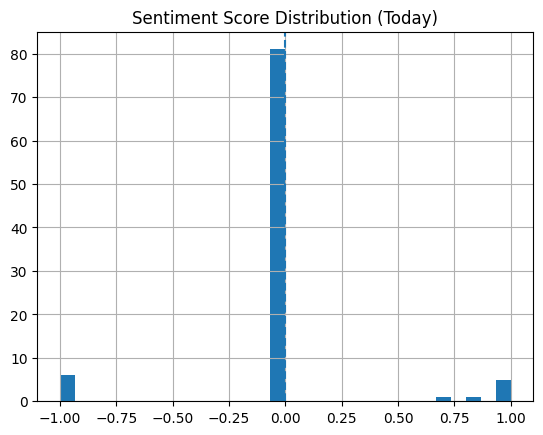

✅ SENTIMENT PIPELINE IS WORKING


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
DAILY_PATH = Path("sentiment_daily.parquet")

# ---- Load ----


df = pd.read_parquet(DAILY_PATH)

# ---- Basic checks ----
rows = len(df)
mean = df["sentiment_score"].mean()
std = df["sentiment_score"].std()
date = pd.to_datetime(df["Date"]).max()

pos = (df["sentiment_score"] > 0).mean() * 100
neg = (df["sentiment_score"] < 0).mean() * 100

print(f"📅 Date: {date.date()}")
print(f"📰 Headlines: {rows}")
print(f"📊 Mean sentiment: {mean:.4f}")
print(f"📈 Std sentiment: {std:.4f}")
print(f"🙂 Positive: {pos:.1f}% | 🙁 Negative: {neg:.1f}%")

# ---- Visual sanity check ----
df["sentiment_score"].hist(bins=30)
plt.title("Sentiment Score Distribution (Today)")
plt.axvline(0, linestyle="--")
plt.show()

# ---- Hard fail conditions ----
assert rows >= 20, "❌ Too few headlines"
assert std > 0, "❌ Sentiment is flat"
assert df["sentiment_score"].abs().max() > 0.1, "❌ No strong signal"

print("✅ SENTIMENT PIPELINE IS WORKING")


In [24]:
import pandas as pd
df = pd.read_parquet("sentiment_rolling_7d.parquet")
print(df.head(100))
print(df.dtypes)

   Ticker  2026-01-29 00:00:00  2026-01-28 00:00:00
0  MARKET                  NaN                  NaN
Ticker                     str
2026-01-29 00:00:00    float64
2026-01-28 00:00:00    float64
dtype: object
